# Homework Starter — Stage 10a: Linear Regression

Use this as a scaffold if your project data isn’t ready. Replace the synthetic data section with your dataset when possible.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st

sns.set()
np.random.seed(7)

## 1) Project Data

This notebook predicts five-day future returns for S&P 500 sector ETFs.

In [3]:
from pathlib import Path
import pandas as pd
ROOT=Path.cwd()
for p in [ROOT,*ROOT.parents]:
 if (p/'project'/'data').exists(): ROOT=p; break
PROJECT_ROOT=ROOT/'project'
df=pd.read_csv(PROJECT_ROOT/'data/processed/sp500_sector_features_stage09.csv',parse_dates=['date'])
df=df.sort_values(['date','ticker']).reset_index(drop=True)
df['future_return_5d']=df.groupby('ticker')['close'].shift(-5)/df['close']-1
df.head()

,date,ticker,close,momentum_5d,daily_return,rolling_mean_return_20d,sector_Communication Services,sector_Consumer Discretionary,sector_Consumer Staples,sector_Energy,sector_Financials,sector_Health Care,sector_Industrials,sector_Information Technology,sector_Materials,sector_Real Estate,sector_Utilities,future_return_5d
0,2021-08-30 13:30:00,XLB,42.930000,NaN,NaN,NaN,0,0,0,0,0,0,0,0,1,0,0,-0.012229
1,2021-08-30 13:30:00,XLC,85.300003,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0.004338
2,2021-08-30 13:30:00,XLE,24.365000,NaN,NaN,NaN,0,0,0,1,0,0,0,0,0,0,0,-0.008208
3,2021-08-30 13:30:00,XLF,38.450001,NaN,NaN,NaN,0,0,0,0,1,0,0,0,0,0,0,-0.015865
4,2021-08-30 13:30:00,XLI,104.800003,NaN,NaN,NaN,0,0,0,0,0,0,1,0,0,0,0,-0.019275


## 2) Baseline model fit
Follow the steps; replace `df` with your project DataFrame when ready.

In [4]:
feature_columns=['daily_return','momentum_5d','rolling_mean_return_20d']
model_df=df.dropna(subset=feature_columns+['future_return_5d']).sort_values('date')
cut=int(len(model_df)*0.8)
train,test=model_df.iloc[:cut],model_df.iloc[cut:]
X_train,X_test=train[feature_columns],test[feature_columns]
y_train,y_test=train['future_return_5d'],test['future_return_5d']
lr=LinearRegression().fit(X_train,y_train)
y_pred=lr.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(f'Baseline R²={r2:.4f} RMSE={rmse:.6f}')

Baseline R²=0.0017 RMSE=0.023948


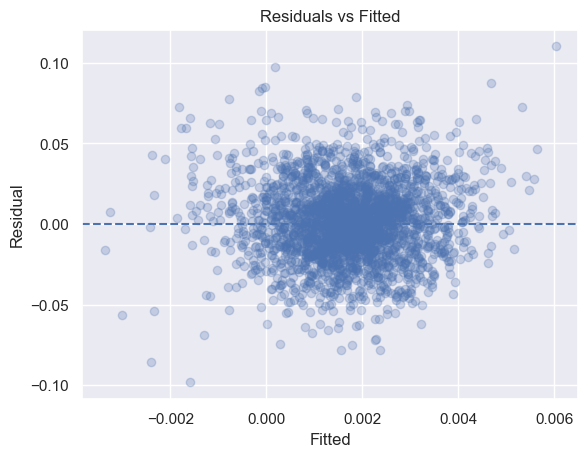

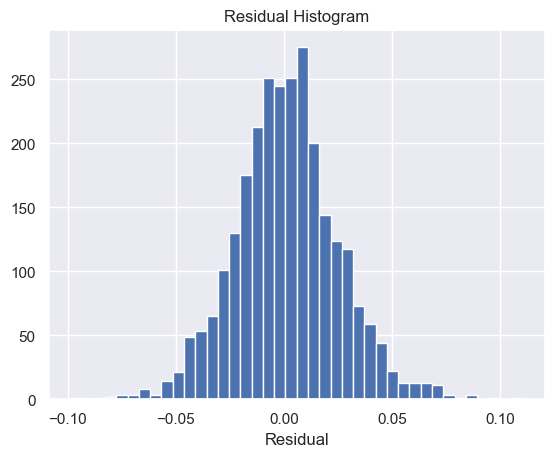

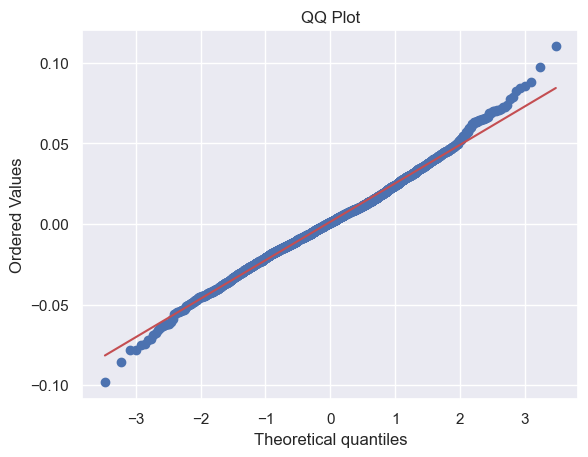

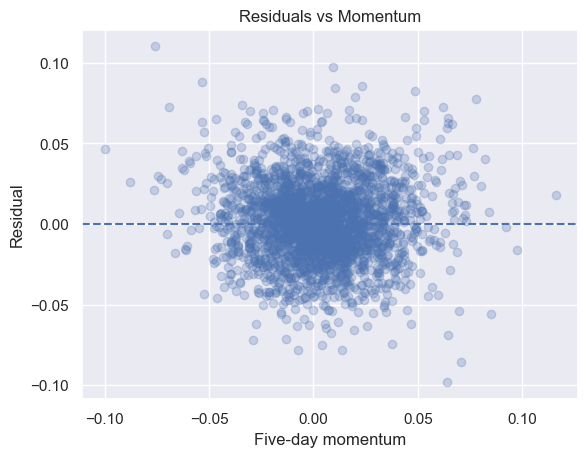

In [5]:
resid=y_test.to_numpy()-y_pred
fitted=y_pred
plt.figure(); plt.scatter(fitted,resid,alpha=.25); plt.axhline(0,ls='--'); plt.xlabel('Fitted'); plt.ylabel('Residual'); plt.title('Residuals vs Fitted'); plt.show()
plt.figure(); plt.hist(resid,bins=40); plt.xlabel('Residual'); plt.title('Residual Histogram'); plt.show()
plt.figure(); st.probplot(resid,dist='norm',plot=plt); plt.title('QQ Plot'); plt.show()
plt.figure(); plt.scatter(test['momentum_5d'],resid,alpha=.25); plt.axhline(0,ls='--'); plt.xlabel('Five-day momentum'); plt.ylabel('Residual'); plt.title('Residuals vs Momentum'); plt.show()

## 3) Optional: Add a Transformed Feature

A squared momentum term tests a possible nonlinear relationship while remaining linear in the model coefficients.

In [6]:
model_df['momentum_sq']=model_df['momentum_5d']**2
X2=model_df[feature_columns+['momentum_sq']]
X2_train,X2_test=X2.iloc[:cut],X2.iloc[cut:]
lr2=LinearRegression().fit(X2_train,y_train)
y_pred2=lr2.predict(X2_test)
print(f'With momentum² R²={r2_score(y_test,y_pred2):.4f} RMSE={np.sqrt(mean_squared_error(y_test,y_pred2)):.6f}')

With momentum² R²=0.0067 RMSE=0.023889


## 4) Interpretation

- **Linearity:** Residuals should be centered around zero without a curved pattern.
- **Homoscedasticity:** A funnel shape would indicate changing residual variance.
- **Normality:** The histogram and QQ plot show whether residuals are approximately normal.
- **Independence:** A visible time pattern would suggest dependent errors.
- **Trust:** This is a limited baseline because short-horizon financial returns are noisy.
- **Next step:** Compare results across market regimes and use time-series validation.